# Pipeline for model training

This notebook implements a complete training pipeline for geo-spatial models. It loads input data from .npz files, applies configurable sampling and dataset splitting strategies, and prepares training, validation, and test sets. The pipeline then trains a model using a simple convolutional neural network (CNN) chosen to ensure compatibility with small $3\times 3$ patches. User-defined parameters such as the sampling strategy and learning rate are set a `config.yaml` file. The notebook ends with a simple evalutation using test accuracy. Additional evaluation is done in the `4_model_evaluation.ipynb` notebook.

Expected input format for the data: .npz files ending in _data.npz. One per aquisition, not a combined one. The code will fetch these from the directory `TRAINING_DATA_DIR`.

Parameters to set in config file:
- sampling strategy
- split strategy
- transforms
- train/test/validation ratio
- channels
- patch size
- batch size
- epochs
- learning rate

### Import libraries and prepare directory paths

In [1]:
import importlib.metadata
import os
import itertools
import yaml
from matplotlib import pyplot as plt
from math import floor
from functools import lru_cache # Cashes results to avoid re-running functions
from pathlib import Path
from pprint import pprint
from typing import Any, Callable, Literal, Self

import lightning.pytorch as pl
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
import torchgeo
from torchgeo.datasets import NonGeoClassificationDataset
from torchgeo.datamodules import NonGeoDataModule
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
from lightning.pytorch.callbacks import Callback

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"TorchGeo version: {torchgeo.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")

PyTorch version: 2.11.0+cu130
TorchGeo version: 0.9.0
PyTorch Lightning version: 2.6.1


In [3]:
# Set user and directory variables
user = "prokop1"
SCRATCH = os.getenv("SCRATCH")

# Options: "normalization_none", "normalization_minmax", "normalization_percentile", "normalization_zscore"
NORMALIZATION_TYPE = "normalization_percentile" # Determines from which directory the training data retrieved

DATA_ROOT = Path(f"{SCRATCH}/{user}/data/")
TRAINING_DATA_DIR = DATA_ROOT / "training_data" / NORMALIZATION_TYPE

assert TRAINING_DATA_DIR.exists(), TRAINING_DATA_DIR

%matplotlib inline

### Configuration

In [4]:
# Opens config file and saves it as cfg
with open(Path() / "config.yaml", mode="r", encoding="utf-8") as src:
    cfg = yaml.safe_load(src)

pprint(cfg)

{'data': {'sampling_strategy': 'weighted',
          'split_strategy': 'stratified',
          'test_ratio': 0.2,
          'train_ratio': 0.6,
          'transforms': {'train': None, 'val': None},
          'val_ratio': 0.2},
 'model': {'in_channels': 4, 'patch_size': 3},
 'training': {'batch_size': 32, 'epochs': 20, 'lr': 0.0001}}


### Corine classes

In [5]:
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    48: "No data",
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


### Functions for data structure 

In [6]:
# Helper function to load data from .npz file
def _parse_npz_file(file_path):
    return np.load(file_path).values()

# Retrieves class distribution
def get_class_distribution(dataset):
    distribution = {
        label.item(): count.item()
        for label, count in zip(*dataset.labels.unique(return_counts=True))
    }
    sorted_distribution = {
        k: v
        for k, v in sorted(distribution.items(), key=lambda item: item[1], reverse=True)
    }

    return sorted_distribution

### Splitting the data intro training/test/validation

In [7]:
# Helper class used for per-class splits when stratification option is used
def get_split(
    sample_indices: torch.Tensor, ratios: list[float], generator: torch.Generator
) -> tuple[torch.Tensor, ...]:

    if len(ratios) == 2:
        _, test_ratio = ratios
        val_ratio = None
    elif len(ratios) == 3:
        _, val_ratio, test_ratio = ratios
    else:
        raise ValueError(
            "Wrong number of ratios provided. Only 2 or 3 ratio values are admitted."
        )

    num_test = max(1, floor(test_ratio * len(sample_indices)))
    num_val = max(1, floor(val_ratio * len(sample_indices))) if val_ratio else 0
    num_train = len(sample_indices) - num_test - num_val

    assert num_train + num_val + num_test == len(sample_indices), (
        "Ratios do not ensure full coverage of samples."
    )

    random_indices = torch.randperm(len(sample_indices), generator=generator)
    slices = [
        slice(0, num_train),
        slice(num_train, num_train + num_val),
        slice(num_train + num_val, num_train + num_val + num_test),
    ]
    train_indices, val_indices, test_indices = [
        sample_indices[random_indices[s]] for s in slices
    ]

    if val_indices.numel() == 0:
        return train_indices, test_indices
    return train_indices, val_indices, test_indices

In [8]:
def make_splits_train_val_test(
    dataset: torch.Tensor,
    labels: torch.Tensor,
    train_frac: float = cfg["data"]["train_ratio"],
    val_frac: float = cfg["data"]["val_ratio"],
    test_frac: float = cfg["data"]["test_ratio"],
    seed: int = 42,
    stratify: bool = True,
) -> tuple[Subset, ...]:
    """
    Train/Val/Test split with optional stratification.

    Requirements:
      train_frac + val_frac + test_frac == 1.0
    """
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train_frac + val_frac + test_frac must be 1.0"

    ratios = [train_frac, val_frac, test_frac]
    generator = torch.Generator().manual_seed(seed)

    if not stratify:
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, ratios, generator=generator
        )
        return train_dataset, val_dataset, test_dataset

    # If stratify, the splits are made on a per-class basis using helper function get_split
    class_indices = [
        torch.argwhere(labels == label).flatten() for label in labels.unique()
    ]
    class_splits = [
        get_split(indices, ratios=ratios, generator=generator)
        for indices in class_indices
    ]
    subset_indices = map(torch.cat, zip(*class_splits))

    return tuple([Subset(dataset, index_set) for index_set in subset_indices])

### Preparing the data

This class consists of methods for loading, combining and splitting data. Additionally, it identifies classes and drops (blacklists) classes that are rare in the data.

In [9]:
class CorineDatasetProcessor:
    """
    Custom Dataset for remote sensing data.

    Parameters:
    -----------
    data : torch.Tensor
        Feature data (n_samples, n_channels, patch_height, patch_width)
    labels : torch.Tensor
        Target labels (n_samples,)
    """

    corine_classes = CORINE_CLASSES

    @classmethod
    def from_npz(cls, folder_path):
        file_paths = folder_path.glob("*_data.npz")
        data, labels = map(np.concatenate, zip(*map(_parse_npz_file, file_paths)))

        return cls(torch.tensor(data), torch.tensor(labels))

    def __init__(self, data: torch.Tensor, labels: torch.Tensor):
        """
        Stores original labels.
        Creates remapping from sparse CORINE id's to continous indices.
        Creates dictionary of class names.
        """

        self.data = data
        self.original_labels = labels

        self.unique_original_labels = self.original_labels.unique()
        self.label_mapping = {
            lbl.item(): i for i, lbl in enumerate(self.unique_original_labels)
        }
        self.reverse_label_mapping = {
            i: lbl.item() for i, lbl in enumerate(self.unique_original_labels)
        }
        self.labels = torch.tensor(
            [self.label_mapping[lbl.item()] for lbl in labels]
        ).type_as(self.original_labels)
        self.unique_labels = self.labels.unique()

        self.class_names = {
            self.label_mapping[lbl.item()]: self.corine_classes[lbl.item()]
            for lbl in self.unique_original_labels
        }

    def drop_labels(self, blacklist: list[int], use_original: bool = True) -> Self:
        """
        Drops labels. Used, for example, to remove small classes.
        """
        if use_original:
            blacklist = [self.reverse_label_mapping[label] for label in blacklist]
        blacklist = torch.tensor(blacklist).type_as(self.original_labels)
        keep_indices = ~torch.isin(self.original_labels, blacklist)
        filtered_data, filtered_orig_labels = (
            self.data[keep_indices],
            self.original_labels[keep_indices],
        )

        return type(self)(filtered_data, filtered_orig_labels)

    def _format_class_name(self, class_name: str) -> str:
        replacements = ((" ", "_"), ("-", "_"))

        for old, new in replacements:
            class_name = class_name.strip().replace(old, new)

        return class_name.lower()

    def create_class_folder(self, root: Path, class_name: str) -> Path:
        """
        Helper function to creates folders for each class.
        """
        folder_name = self._format_class_name(class_name)
        folder_path = root / folder_name
        folder_path.mkdir(parents=True, exist_ok=True) # Avoids crash of folder already exist
        return folder_path.resolve()

    def create_imagefolder_structure(
        self, root: os.PathLike | Path, split: str) -> dict[int, Path]:
        """
        Creates class folders for the split.
        """
        split_folder = Path(root) / split
        class_folder_router = {
            idx: self.create_class_folder(split_folder, class_name)
            for idx, class_name in self.class_names.items()
        }

        return class_folder_router

    def save_split(self, split_indices: Subset, root: os.PathLike | Path, split: str):
        """
        Saves the split's patches to class folders.
        Skips if the file already exists.
        """
        folder_router = self.create_imagefolder_structure(root, split)
        data, labels = self.data[split_indices], self.labels[split_indices]
    
        assert len(data) == len(labels) and len(data) > 0
    
        n = len(data)
        skipped = 0
    
        for i, (idx, patch, label) in enumerate(zip(split_indices, data, labels), 1):
            filepath = folder_router[label.item()] / f"{idx}.npy"
    
            if filepath.exists():
                skipped += 1
            else:
                np.save(filepath, patch.numpy())
    
            if i % 10000 == 0 or i == n:
                print(f"{split}: {i}/{n} processed (skipped {skipped})")
    

    def make_splits(self, root: os.PathLike | Path, **kwargs):
        """
        Splits the data into training, validation and test.
        Uses either a random or a stratified split.
        """
        stratify = kwargs.get("split_strategy", "random") == "stratified"
        print(f"Creating splits (stratify={stratify})...")

        subsets = make_splits_train_val_test(
            self.data,
            self.labels,
            train_frac=kwargs["train_ratio"],
            val_frac=kwargs["val_ratio"],
            test_frac=kwargs["test_ratio"],
            stratify=stratify,
        )
        print("Splits created.")
        print(f"Train: {len(subsets[0])}, Val: {len(subsets[1])}, Test: {len(subsets[2])}")
        
        # Save split
        for subset, split in zip(subsets, ["train", "val", "test"]):
            print(f"Saving {split} split with {len(subset)} samples...")
            self.save_split(subset.indices, root, split)
            print(f"Finished saving {split} split.")

        return subsets


In [10]:
# Creates a CorineDatasetProcessor instance, loading training data from TRAINING_DATA_DIR
processor = CorineDatasetProcessor.from_npz(TRAINING_DATA_DIR)

### Information about classes and their distribution

In [11]:
processor.class_names

{0: 'Discontinuous urban fabric',
 1: 'Non-irrigated arable land',
 2: 'Agriculture with natural vegetation',
 3: 'Coniferous forest',
 4: 'Mixed forest',
 5: 'Transitional woodland-shrub',
 6: 'Peat bogs',
 7: 'Water bodies'}

In [12]:
# Print information about the class distributions in the full data set
class_distribution = get_class_distribution(processor)

print("Labels distribution")
print(class_distribution)

print("\nLabel distribution (%)")
total = sum(class_distribution.values())

class_percentages = {
    cls: count / total * 100
    for cls, count in class_distribution.items()
}

print({cls: f"{pct:.2f}%" for cls, pct in class_percentages.items()})

print("\nMapping")
print(processor.label_mapping)

Labels distribution
{3: 69097, 1: 8380, 5: 7107, 4: 4621, 7: 4445, 6: 2323, 0: 2083, 2: 1944}

Label distribution (%)
{3: '69.10%', 1: '8.38%', 5: '7.11%', 4: '4.62%', 7: '4.45%', 6: '2.32%', 0: '2.08%', 2: '1.94%'}

Mapping
{2: 0, 12: 1, 21: 2, 24: 3, 25: 4, 29: 5, 36: 6, 41: 7}


In [13]:
# Blacklists classes that have less than 10 occurances in the data
blacklist = [idx for idx in class_distribution if class_distribution[idx] < 10]
print(blacklist)

[]


Since no classes are blacklisted, there is no need to use `processor = processor.drop_labels(blacklist)` to drop them.

In [14]:
# processor = processor.drop_labels(blacklist)

### Splitting the data

In [15]:
# Splitting the patches into train/val/test and saving them per split and class
dataset_folder = Path(DATA_ROOT / "processed" / NORMALIZATION_TYPE)
train_subset, val_subset, test_subset = processor.make_splits(
    dataset_folder, **cfg["data"]
)

Creating splits (stratify=True)...
Splits created.
Train: 60006, Val: 19997, Test: 19997
Saving train split with 60006 samples...
train: 10000/60006 processed (skipped 0)
train: 20000/60006 processed (skipped 0)
train: 30000/60006 processed (skipped 0)
train: 40000/60006 processed (skipped 0)
train: 50000/60006 processed (skipped 0)
train: 60000/60006 processed (skipped 0)
train: 60006/60006 processed (skipped 0)
Finished saving train split.
Saving val split with 19997 samples...
val: 10000/19997 processed (skipped 0)
val: 19997/19997 processed (skipped 0)
Finished saving val split.
Saving test split with 19997 samples...
test: 10000/19997 processed (skipped 0)
test: 19997/19997 processed (skipped 0)
Finished saving test split.


In [16]:
# Printing number of samples and labels present in all three splits
print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_subset)}")
train_labels = processor.labels[train_subset.indices]
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_subset)}")
val_labels = processor.labels[val_subset.indices]
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_subset)}")
test_labels = processor.labels[test_subset.indices]
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 60006
# Training labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 19997
# Validation labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 19997
# Test labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


From the subsets summary, we can see that there are no classes missing from any of the three splits.

In [17]:
# Sanity check label distribution
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)

    k = min(topk, len(vals))
    print(f"\n{name} label distribution (ranked by frequency):")

    for rank, (v, c) in enumerate(zip(vals[order][:k], cnts[order][:k]), start=1):
        orig = processor.reverse_label_mapping[int(v)]
        print(f"  #{rank:2d} | idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 41459
  # 2 | idx  1 (CORINE 12): 5028
  # 3 | idx  5 (CORINE 29): 4265
  # 4 | idx  4 (CORINE 25): 2773
  # 5 | idx  7 (CORINE 41): 2667
  # 6 | idx  6 (CORINE 36): 1395
  # 7 | idx  0 (CORINE  2): 1251
  # 8 | idx  2 (CORINE 21): 1168

Val label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 13819
  # 2 | idx  1 (CORINE 12): 1676
  # 3 | idx  5 (CORINE 29): 1421
  # 4 | idx  4 (CORINE 25): 924
  # 5 | idx  7 (CORINE 41): 889
  # 6 | idx  6 (CORINE 36): 464
  # 7 | idx  0 (CORINE  2): 416
  # 8 | idx  2 (CORINE 21): 388

Test label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 13819
  # 2 | idx  1 (CORINE 12): 1676
  # 3 | idx  5 (CORINE 29): 1421
  # 4 | idx  4 (CORINE 25): 924
  # 5 | idx  7 (CORINE 41): 889
  # 6 | idx  6 (CORINE 36): 464
  # 7 | idx  0 (CORINE  2): 416
  # 8 | idx  2 (CORINE 21): 388


From the ranked lists, we can see that the validation set and test set have identical distributions. The order of the labels are the same in all three splits.  

In [18]:
# Show error if the sets overlap
assert set() == set(train_subset.indices.tolist()) & set(val_subset.indices.tolist())
assert set() == set(val_subset.indices.tolist()) & set(test_subset.indices.tolist())
assert set() == set(train_subset.indices.tolist()) & set(test_subset.indices.tolist())

### Dataset class

In [19]:
class CorineDataset(NonGeoClassificationDataset):
    """
    Custom dataset class for loading pre-split land cover data using TorchGeo.
    """
    splits = ("train", "val", "test")
    valid_extensions = (".npy", ".npz", ".safetensors")

    def __init__(
        self,
        root: Path,
        split: Literal["train", "val", "test"],
        transforms: Callable[[Any], Any] | None = None,
    ) -> None:

        self.split = split

        def is_valid_file(path: str) -> bool:
            return Path(path).suffix in self.valid_extensions

        super().__init__(
            root=root / self.split,
            transforms=transforms,
            loader=np.load,
            is_valid_file=is_valid_file,
        )

    def compute_class_weights(self):
        """
        Calculates multiplicative inverse (reciprocal) class weights.
        """
        samples_per_class = [
            len(list((self.root / class_name).glob("*.npy")))
            for class_name in self.classes
        ]
        class_weights = torch.reciprocal(
            torch.tensor(samples_per_class, dtype=torch.float64)
        )
        weights_mapping = {idx: value.item() for idx, value in enumerate(class_weights)}

        return weights_mapping

In [20]:
# Create instances of the class CorineDataset for training, validation and test data
train_dataset = CorineDataset(root=dataset_folder, split="train")
val_dataset = CorineDataset(root=dataset_folder, split="val")
test_dataset = CorineDataset(root=dataset_folder, split="test")

In [21]:
# Sanity check comparing labels with original file for each split
train_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (train_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in train_dataset.classes
            ]
        )
    )
).type_as(train_subset.indices)
assert torch.equal(
    torch.sort(train_subset.indices)[0], torch.sort(train_class_indices)[0]
)

val_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (val_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in val_dataset.classes
            ]
        )
    )
).type_as(val_subset.indices)
assert torch.equal(torch.sort(val_subset.indices)[0], torch.sort(val_class_indices)[0])

test_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (test_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in test_dataset.classes
            ]
        )
    )
).type_as(test_subset.indices)
assert torch.equal(
    torch.sort(test_subset.indices)[0], torch.sort(test_class_indices)[0])

torch.Size([3, 3, 4])


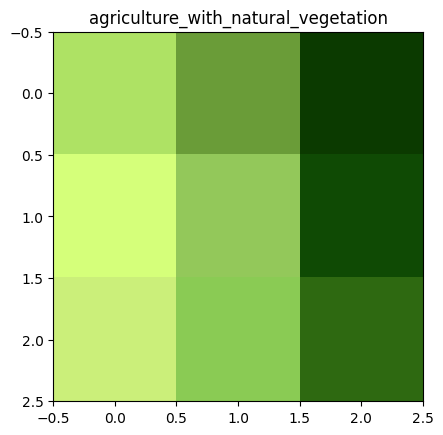

In [22]:
# Show a sample
sample = train_dataset[81]

arr = sample["image"].permute(2, 1, 0)
print(arr.shape)
rgb = arr[:, :, [2, 1, 0]]
#rgb = np.clip(rgb, 0, 1)  # Ensure in [0, 1]

# Auto-normalize for display for varying normalizations
rgb_min = rgb.min()
rgb_max = rgb.max()

if rgb_max > rgb_min:
    rgb = (rgb - rgb_min) / (rgb_max - rgb_min)

plt.imshow(rgb)
plt.title(train_dataset.classes[sample["label"].item()])
plt.show()

In [23]:
# Sanity check of class names and index mapping
# "class name" → internal idx → original CORINE class ID
reverse_classnames = {
    name.strip().replace(" ", "_").replace("-", "_").lower(): idx
    for idx, name in processor.class_names.items()}

remap_names, remap_indices = zip(
    *sorted(list(reverse_classnames.items()), key=lambda item: item[0])
)
assert list(remap_names) == train_dataset.classes
print(remap_indices)

(2, 3, 0, 4, 1, 6, 5, 7)


In [24]:
# Printing the class weights
class_weights = train_dataset.compute_class_weights()
pprint(class_weights)

{0: 0.0008561643835616438,
 1: 2.4120215152319158e-05,
 2: 0.0007993605115907274,
 3: 0.0003606202668589975,
 4: 0.0001988862370723946,
 5: 0.0007168458781362007,
 6: 0.00023446658851113716,
 7: 0.0003749531308586427}


In [25]:
# Show mapping of class names to weights
pprint(dict(zip(train_dataset.classes, class_weights.values())))

{'agriculture_with_natural_vegetation': 0.0008561643835616438,
 'coniferous_forest': 2.4120215152319158e-05,
 'discontinuous_urban_fabric': 0.0007993605115907274,
 'mixed_forest': 0.0003606202668589975,
 'non_irrigated_arable_land': 0.0001988862370723946,
 'peat_bogs': 0.0007168458781362007,
 'transitional_woodland_shrub': 0.00023446658851113716,
 'water_bodies': 0.0003749531308586427}


### Data module class

Custom datamodule implementing the `NonGeoDataModule` interface from torchgeo. Implements weighted sampling to better handle the very uneven distribution of classes.

In [26]:
class CorineDataModule(NonGeoDataModule):
    """
    Standard NonGeoDataModule with added (optional) weighted sampling.
    """
    @lru_cache
    def _get_sample_weights(self) -> torch.Tensor:

        class_weights = self.train_dataset.compute_class_weights()
        sample_weights = torch.tensor(
            [class_weights[sample["label"].item()] for sample in self.train_dataset]
        )

        return sample_weights

    def train_dataloader(self) -> DataLoader:
        sampling_strategy = cfg["data"].get("sampling_strategy", None)
        if not sampling_strategy == "weighted":
            print("Defaulting to random sampling in dataloader...")
            return super().train_dataloader()
        print("Using weighted sampler...")

        sample_weights = self._get_sample_weights()
        num_samples = len(sample_weights)
        assert num_samples == len(self.train_dataset)

        self.sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=num_samples,
            replacement=True,
        )

        return DataLoader(
            self.train_dataset,
            batch_size=cfg["training"]["batch_size"],
            shuffle=False,
            sampler=self.sampler,
            num_workers=2,
            pin_memory=True,
        )

In [27]:
# Creates and initializes the custom data module and prepares it for the fit stage
# %%timeit
dataset_folder = Path(DATA_ROOT / "processed" / NORMALIZATION_TYPE)
corine_datamodule = CorineDataModule(
    CorineDataset,
    root=dataset_folder,
    batch_size=cfg["training"]["batch_size"],
    num_workers=2,
)

corine_datamodule.setup("fit")

In [28]:
# Prints the class sample weights
sample_weights = corine_datamodule._get_sample_weights()
pprint(sample_weights.unique(return_counts=True))

(tensor([2.4120e-05, 1.9889e-04, 2.3447e-04, 3.6062e-04, 3.7495e-04, 7.1685e-04,
        7.9936e-04, 8.5616e-04]),
 tensor([41459,  5028,  4265,  2773,  2667,  1395,  1251,  1168]))


In [29]:
# Prints the weights per class with the class names
weights = corine_datamodule.train_dataset.compute_class_weights()
pprint(dict(zip(corine_datamodule.train_dataset.classes, weights.values())))

{'agriculture_with_natural_vegetation': 0.0008561643835616438,
 'coniferous_forest': 2.4120215152319158e-05,
 'discontinuous_urban_fabric': 0.0007993605115907274,
 'mixed_forest': 0.0003606202668589975,
 'non_irrigated_arable_land': 0.0001988862370723946,
 'peat_bogs': 0.0007168458781362007,
 'transitional_woodland_shrub': 0.00023446658851113716,
 'water_bodies': 0.0003749531308586427}


### Trainer

In [30]:
# Callbacks for CNN

class ClassDistributionCallback(Callback):
    """
    Calculates label distribution for each batch and computes the per-epoch mean.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.train_class_counts = []
        self.val_class_counts = []

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        labels = batch["label"]
        counts = torch.bincount(labels, minlength=self.num_classes).cpu()
        self.train_class_counts.append(counts)

    def on_validation_batch_start(self, trainer, pl_module, batch, batch_idx, dataloader_idx=0):
        labels = batch["label"]
        counts = torch.bincount(labels, minlength=self.num_classes).cpu()
        self.val_class_counts.append(counts)

    def on_train_epoch_end(self, trainer, pl_module):
        if self.train_class_counts:
            train_dist = torch.stack(self.train_class_counts).float().mean(dim=0)
            trainer.train_class_dist = train_dist
            self.train_class_counts.clear()

    def on_validation_epoch_end(self, trainer, pl_module):
        if self.val_class_counts:
            val_dist = torch.stack(self.val_class_counts).float().mean(dim=0)
            trainer.val_class_dist = val_dist
            self.val_class_counts.clear()

class ValidationAccuracyCallback(Callback):
    """
    Calculates validation accuracy for each epoch for logging.
    """
    def on_validation_epoch_end(self, trainer, pl_module):
        # Access validation accuracy from logged metrics
        val_acc = trainer.callback_metrics.get("val/Accuracy")
        # print(f"Validation Accuracy: {val_acc.item():.4f}")

        if val_acc is not None:
            print(f"Validation Accuracy: {val_acc.item():.4f}")

In [31]:
# Configures the PyTorch Lightning Trainer that will run CNN

classes = corine_datamodule.train_dataset.classes # Reads and stores training set classes
pl.seed_everything(0) # For reproducibility

# Callback to save model checkpoints
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=DATA_ROOT / "training_logs" / NORMALIZATION_TYPE,
    monitor="val_acc", # Metric used to compare models
    mode="max", # Keeps model with maximum validation accuracy
    filename="{epoch}-{val_loss:.2f}-{val_acc:.2f}",
    save_weights_only=True, # Only saves model weights
)

# Instansiates the PyTorch Lightning Trainer
trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=int(cfg["training"]["epochs"]),
    logger=False,
    log_every_n_steps=1,
    devices=1, # Only one GPU is used due to limiatations in the live Jupyter Notebook
    callbacks=[
        checkpoint_callback,
        ClassDistributionCallback(num_classes=len(classes)),
        ValidationAccuracyCallback(),
        pl.callbacks.RichProgressBar(),
    ],
)

[rank: 0] Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Convolutional Network

Custom PyTorch Lightning model class for a simple CNN. 

In [32]:
class ConvNet(pl.LightningModule):
    def __init__(
        self,
        num_classes,
        in_channels=4,
        patch_size=3,
        lr=3e-4,
        max_epochs=60,
        class_weights=None, # If provided, weighted loss will be used
    ):
        super().__init__()
        # Save hyperparameters except class_weights
        self.save_hyperparameters(ignore=["class_weights"])

        # Store key hyperparameters
        self.in_channels = in_channels
        self.patch_size = patch_size
        self.lr = lr
        self.max_epochs = max_epochs
        
        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1), # First convolutional layer
            nn.BatchNorm2d(64), # Normalization layer
            nn.ReLU(inplace=True), # Activation function
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # Second convolutional layer
            nn.BatchNorm2d(128), # Normalization layer
            nn.ReLU(inplace=True), # Activation layer
            nn.AdaptiveAvgPool2d((1, 1)), # Reduce spatial dimensions
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(), # Flatten the input
            nn.Linear(128, 64),
            nn.ReLU(), # Activation function
            nn.Dropout(0.3), # Regularization to reduce overfitting
            nn.Linear(64, num_classes), # Output layer
        )

        # Optional class-weighted loss for class imbalance
        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.float())
        else:
            self.class_weights = None
            
        # Metrics tracked across validation/test epochs
        self.val_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)
        self.test_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)

    def forward(self, x):
        # Runs feature extractor and classifier in sequence
        x = x.float()
        return self.classifier(self.features(x))

    def _loss(self, logits, y):
        # Cross-entropy loss with optional class weights
        # Note: The weighted loss should not be used if weighted sampling has already been done
        return F.cross_entropy(logits, y, weight=self.class_weights)

    def training_step(self, batch, batch_idx):
        # Training step: Compute loss and log it each epoch
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        # Validation step: compute loss + accuracy metric update
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)
        preds = logits.argmax(dim=1)

        self.val_acc.update(preds, y)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        self.log("val_acc", self.val_acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))

    def test_step(self, batch, batch_idx):
        # Test step: compute loss + accuracy metric update
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)
        preds = logits.argmax(dim=1)

        self.test_acc.update(preds, y)

        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        self.log("test_acc", self.test_acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))

    def configure_optimizers(self):
        # AdamW optimizer with cosine annealing learning-rate scheduler
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sched}

In [33]:
# Task for CNN
task = ConvNet(
    num_classes=len(classes),
    in_channels=int(cfg["model"]["in_channels"]),
    patch_size=int(cfg["model"]["patch_size"]),
    lr=float(cfg["training"]["lr"]),
    max_epochs=int(cfg["training"]["epochs"]),
    class_weights=None, # Set to none to avoid using Weighted Loss since already used Weighted Sampling
)

In [34]:
# Fit the model
trainer.fit(model=task, datamodule=corine_datamodule)

Epoch 19/19 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1876/1876 0:00:17 • 0:00:00 107.39it/s val_loss: 1.296 val_acc: 0.555  
                                                                                   train_loss: 1.222               

`Trainer.fit` stopped: `max_epochs=20` reached.


In [35]:
print("Average train batch class distribution:")
for i, count in enumerate(trainer.train_class_dist):
    print(f"  {classes[i]}: {count.item():.2f}")

print("\nAverage val batch class distribution:")
for i, count in enumerate(trainer.val_class_dist):
    print(f"  {classes[i]}: {count.item():.2f}")

Average train batch class distribution:
  agriculture_with_natural_vegetation: 4.01
  coniferous_forest: 3.91
  discontinuous_urban_fabric: 4.02
  mixed_forest: 4.03
  non_irrigated_arable_land: 3.97
  peat_bogs: 4.04
  transitional_woodland_shrub: 3.98
  water_bodies: 4.03

Average val batch class distribution:
  agriculture_with_natural_vegetation: 0.62
  coniferous_forest: 22.11
  discontinuous_urban_fabric: 0.67
  mixed_forest: 1.48
  non_irrigated_arable_land: 2.68
  peat_bogs: 0.74
  transitional_woodland_shrub: 2.27
  water_bodies: 1.42


In [36]:
# Test the model
trainer.test(model=task, datamodule=corine_datamodule)

Testing ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625/625 0:00:27 • 0:00:00 22.60it/s

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.54795241355896      │
│         test_loss         │    1.3070290088653564     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.3070290088653564, 'test_acc': 0.54795241355896}]

### Prepare data for export to Evaluation notebook

In [37]:
def collect_preds_targets(model, dataloader):
    """
    Collects predictions on test set.
    """
    model.eval()
    device = next(model.parameters()).device

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for batch in dataloader:
            xb = batch["image"].to(device)
            yb = batch["label"]

            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = yb.cpu().numpy()

            preds_all.append(preds)
            targets_all.append(targets)

    y_pred = np.concatenate(preds_all).astype(np.int64)
    y_true = np.concatenate(targets_all).astype(np.int64)
    return y_true, y_pred

In [38]:
# Loading test data and extracting test set predictions and true values
test_loader = corine_datamodule.test_dataloader()
y_true, y_pred = collect_preds_targets(task, test_loader)

# Storing class names
class_names = np.array(classes, dtype=object)

print(y_true.shape, y_pred.shape)
print(class_names)

(19997,) (19997,)
['agriculture_with_natural_vegetation' 'coniferous_forest'
 'discontinuous_urban_fabric' 'mixed_forest' 'non_irrigated_arable_land'
 'peat_bogs' 'transitional_woodland_shrub' 'water_bodies']


In [39]:
# Saving outputs (y_true, y_pred, class_names) for evaluation
EVAL_PATH = Path(DATA_ROOT) / "evaluation"/ NORMALIZATION_TYPE / "evaluation_outputs.npz"
if not EVAL_PATH.parent.exists():
    EVAL_PATH.parent.mkdir(parents=True, exist_ok=True)

np.savez(
    EVAL_PATH,
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
)

print(f"Saved evaluation data to: {EVAL_PATH}")

Saved evaluation data to: /p/scratch/training2600/prokop1/data/evaluation/normalization_percentile/evaluation_outputs.npz
